In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("tmdb_movies_1990_2025.csv")

print(df.shape)
print(df.columns.tolist())
print(df.head(3))

(27027, 18)
['id', 'title', 'release_date', 'year', 'vote_average', 'vote_count', 'popularity', 'budget', 'revenue', 'runtime', 'original_language', 'genres', 'director', 'actor1', 'actor2', 'actor3', 'actor4', 'actor5']
    id                title release_date    year  vote_average  vote_count  \
0  769           GoodFellas   1990-09-12  1990.0         8.453     14184.0   
1  162  Edward Scissorhands   1990-12-07  1990.0         7.720     13674.0   
2  771           Home Alone   1990-11-16  1990.0         7.463     12400.0   

   popularity      budget      revenue  runtime original_language  \
0     25.0553  25000000.0   47072327.0    145.0                en   
1      9.7848  20000000.0   86024005.0    105.0                en   
2      0.7894  18000000.0  476684675.0    103.0                en   

                  genres         director           actor1        actor2  \
0            Drama|Crime  Martin Scorsese   Robert De Niro    Ray Liotta   
1  Fantasy|Drama|Romance       Tim Bu

In [2]:
# Temel temizlik
df['year'] = pd.to_numeric(df['year'], errors='coerce')
df['budget'] = pd.to_numeric(df['budget'], errors='coerce').fillna(0)
df['revenue'] = pd.to_numeric(df['revenue'], errors='coerce').fillna(0)
df['runtime'] = pd.to_numeric(df['runtime'], errors='coerce')
df['vote_average'] = pd.to_numeric(df['vote_average'], errors='coerce')

# Runtime eksiklerini medyan ile doldur
df['runtime'] = df['runtime'].fillna(df['runtime'].median())

# Bilinmeyen oyuncu/yönetmen
actor_cols = ['actor1', 'actor2', 'actor3', 'actor4', 'actor5']
for col in actor_cols:
    df[col] = df[col].fillna('Unknown')
df['director'] = df['director'].fillna('Unknown')

# Hedef değişken
df['target'] = (df['vote_average'] > 7).astype(int)

print(df.shape)
print(df['target'].value_counts())
print(df.isnull().sum())

(27027, 19)
target
0    21528
1     5499
Name: count, dtype: int64
id                     0
title                480
release_date         483
year                 483
vote_average         483
vote_count           483
popularity           483
budget                 0
revenue                0
runtime                0
original_language    483
genres               495
director               0
actor1                 0
actor2                 0
actor3                 0
actor4                 0
actor5                 0
target                 0
dtype: int64


In [3]:
# 10 eksik genres satırını at
df = df.dropna(subset=['genres']).copy()
print(df.shape)

# Genre one-hot encoding
genre_dummies = df['genres'].str.get_dummies(sep='|')
print(genre_dummies.columns.tolist())
print(genre_dummies.shape)

(26532, 19)
['Action', 'Adventure', 'Animation', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Family', 'Fantasy', 'History', 'Horror', 'Music', 'Mystery', 'Romance', 'Science Fiction', 'TV Movie', 'Thriller', 'War', 'Western']
(26532, 19)


In [4]:
from sklearn.model_selection import train_test_split

# Genre'yi df'e ekle
df = pd.concat([df, genre_dummies], axis=1)

# Dil encoding
top_langs = df['original_language'].value_counts().nlargest(10).index
df['language_encoded'] = df['original_language'].apply(
    lambda x: x if x in top_langs else 'other'
)
df = pd.get_dummies(df, columns=['language_encoded'], prefix='lang')

# ÖNCE SPLIT — leak önleme
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)
print(f"Train: {len(train_df)}, Test: {len(test_df)}")

Train: 21225, Test: 5307


In [5]:
# SADECE TRAIN üzerinden hesapla
actor_cols = ['actor1', 'actor2', 'actor3', 'actor4', 'actor5']
global_mean = train_df['vote_average'].mean()

# Director
director_avg = train_df.groupby('director')['vote_average'].mean()
director_exp = train_df.groupby('director')['id'].count()

# Actor
all_actors_train = pd.concat([
    train_df[['vote_average', col]].rename(columns={col: 'actor'})
    for col in actor_cols
])
actor_avg = all_actors_train.groupby('actor')['vote_average'].mean()
actor_exp = all_actors_train.groupby('actor')['vote_average'].count()

def add_features(df_):
    df_ = df_.copy()
    df_['director_avg_rating'] = df_['director'].map(director_avg).fillna(global_mean)
    df_['director_experience'] = df_['director'].map(director_exp).fillna(0)

    def cast_avg(row):
        known = [a for a in row if a != 'Unknown' and a in actor_avg.index]
        return actor_avg[known].mean() if known else global_mean

    def cast_exp(row):
        known = [a for a in row if a != 'Unknown' and a in actor_exp.index]
        return actor_exp[known].mean() if known else 0

    df_['cast_avg_rating'] = df_[actor_cols].apply(cast_avg, axis=1)
    df_['cast_experience'] = df_[actor_cols].apply(cast_exp, axis=1)
    return df_

train_df = add_features(train_df)
test_df  = add_features(test_df)

print(train_df[['director_avg_rating', 'cast_avg_rating', 'cast_experience']].describe())

       director_avg_rating  cast_avg_rating  cast_experience
count         21225.000000     21225.000000     21225.000000
mean              6.298691         6.293440         9.200806
std               0.755626         0.596861         7.404747
min               1.848000         2.200600         0.000000
25%               5.863500         5.992700         3.200000
50%               6.350000         6.299545         7.200000
75%               6.800000         6.613413        13.400000
max               9.900000         9.270000        68.000000


In [6]:
genre_cols = genre_dummies.columns.tolist()
lang_cols  = [c for c in train_df.columns if c.startswith('lang_')]

feature_cols = [
    'popularity', 'runtime', 'budget', 'revenue', 'year',
    'director_avg_rating', 'director_experience',
    'cast_avg_rating', 'cast_experience',
] + genre_cols + lang_cols

X_train = train_df[feature_cols]
X_test  = test_df[feature_cols]
y_train = train_df['target']
y_test  = test_df['target']

print(f"Feature sayısı: {len(feature_cols)}")
print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")
print(X_train.isnull().sum().sum(), "eksik değer")

Feature sayısı: 39
X_train: (21225, 39), X_test: (5307, 39)
0 eksik değer


In [7]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.model_selection import cross_val_score

# Model
model = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
model.fit(X_train, y_train)

# Test sonuçları
y_pred = model.predict(X_test)
print("Test doğruluğu:", round(accuracy_score(y_test, y_pred), 3))
print(classification_report(y_test, y_pred, target_names=['Kötü film', 'İyi film']))

# Cross-validation
scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy', n_jobs=-1)
print(f"CV Ortalama: {scores.mean():.3f} ± {scores.std():.3f}")
print(f"Foldlar: {[round(s,3) for s in scores]}")

Test doğruluğu: 0.813
              precision    recall  f1-score   support

   Kötü film       0.86      0.91      0.89      4223
    İyi film       0.56      0.42      0.48      1084

    accuracy                           0.81      5307
   macro avg       0.71      0.67      0.68      5307
weighted avg       0.80      0.81      0.80      5307

CV Ortalama: 0.919 ± 0.002
Foldlar: [np.float64(0.919), np.float64(0.92), np.float64(0.915), np.float64(0.922), np.float64(0.92)]


In [8]:
from sklearn.utils import resample

# Oversampling — iyi film sayısını kötü film sayısına eşitle
train_majority = train_df[train_df['target'] == 0]
train_minority = train_df[train_df['target'] == 1]

train_minority_upsampled = resample(
    train_minority,
    replace=True,
    n_samples=len(train_majority),
    random_state=42
)

train_balanced = pd.concat([train_majority, train_minority_upsampled])
print(train_balanced['target'].value_counts())

X_train_bal = train_balanced[feature_cols]
y_train_bal = train_balanced['target']

# Modeli dengeli veriyle yeniden eğit
model2 = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)
model2.fit(X_train_bal, y_train_bal)

y_pred2 = model2.predict(X_test)
print("\nTest doğruluğu:", round(accuracy_score(y_test, y_pred2), 3))
print(classification_report(y_test, y_pred2, target_names=['Kötü film', 'İyi film']))

target
0    16814
1    16814
Name: count, dtype: int64

Test doğruluğu: 0.813
              precision    recall  f1-score   support

   Kötü film       0.86      0.91      0.89      4223
    İyi film       0.56      0.43      0.48      1084

    accuracy                           0.81      5307
   macro avg       0.71      0.67      0.68      5307
weighted avg       0.80      0.81      0.80      5307



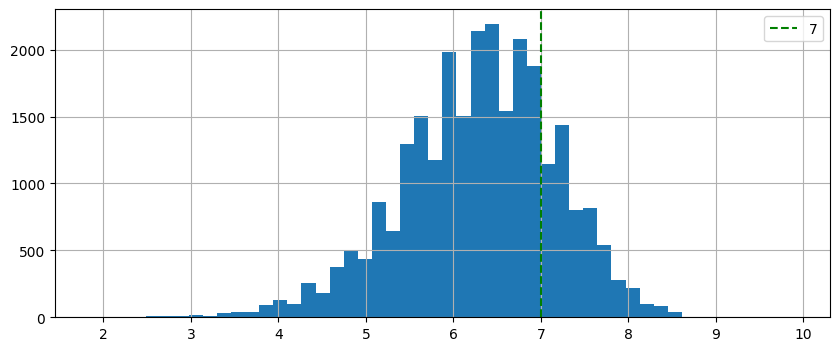

count    26532.000000
mean         6.294774
std          0.883386
min          1.848000
25%          5.741000
50%          6.341500
75%          6.900000
max          9.900000
Name: vote_average, dtype: float64


In [9]:
import matplotlib.pyplot as plt
df['vote_average'].hist(bins=50, figsize=(10,4))
plt.axvline(7, color='g', linestyle='--', label='7')
plt.legend()
plt.show()
print(df['vote_average'].describe())

In [10]:
def kategorize2(x):
    if x < 6:
        return 'kötü'
    elif x <= 7:
        return 'ortalama'
    else:
        return 'iyi'

df['kategori'] = df['vote_average'].apply(kategorize2)
print(df['kategori'].value_counts())
print(df['kategori'].value_counts(normalize=True).round(3))

kategori
ortalama    12207
kötü         8830
iyi          5495
Name: count, dtype: int64
kategori
ortalama    0.460
kötü        0.333
iyi         0.207
Name: proportion, dtype: float64


In [11]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import LabelEncoder

# Hedef değişkeni güncelle
le = LabelEncoder()
train_df['target3'] = le.fit_transform(train_df['vote_average'].apply(kategorize2))
test_df['target3']  = le.transform(test_df['vote_average'].apply(kategorize2))

print("Sınıf sırası:", le.classes_)

y_train3 = train_df['target3']
y_test3  = test_df['target3']

# Gradient Boosting
from sklearn.ensemble import HistGradientBoostingClassifier  # hızlı versiyon

model3 = HistGradientBoostingClassifier(
    max_iter=300,
    max_depth=6,
    learning_rate=0.05,
    class_weight='balanced',
    random_state=42
)
model3.fit(X_train, y_train3)

y_pred3 = model3.predict(X_test)
print("Test doğruluğu:", round(accuracy_score(y_test3, y_pred3), 3))
print(classification_report(y_test3, y_pred3, target_names=le.classes_))

Sınıf sırası: ['iyi' 'kötü' 'ortalama']
Test doğruluğu: 0.541
              precision    recall  f1-score   support

         iyi       0.56      0.41      0.47      1084
        kötü       0.61      0.42      0.50      1817
    ortalama       0.51      0.69      0.59      2406

    accuracy                           0.54      5307
   macro avg       0.56      0.51      0.52      5307
weighted avg       0.55      0.54      0.53      5307



In [12]:
# Sadece iyi ve kötü filmler
train_binary = train_df[train_df['vote_average'].apply(kategorize2) != 'ortalama'].copy()
test_binary  = test_df[test_df['vote_average'].apply(kategorize2) != 'ortalama'].copy()

train_binary['target_b'] = (train_binary['vote_average'] > 7).astype(int)
test_binary['target_b']  = (test_binary['vote_average'] > 7).astype(int)

print(f"Train: {len(train_binary)}, Test: {len(test_binary)}")
print(train_binary['target_b'].value_counts())

model4 = HistGradientBoostingClassifier(
    max_iter=300,
    max_depth=6,
    learning_rate=0.05,
    class_weight='balanced',
    random_state=42
)
model4.fit(train_binary[feature_cols], train_binary['target_b'])

y_pred4 = model4.predict(test_binary[feature_cols])
print("\nTest doğruluğu:", round(accuracy_score(test_binary['target_b'], y_pred4), 3))
print(classification_report(test_binary['target_b'], y_pred4,
      target_names=['Kötü film', 'İyi film']))

Train: 11424, Test: 2901
target_b
0    7013
1    4411
Name: count, dtype: int64

Test doğruluğu: 0.824
              precision    recall  f1-score   support

   Kötü film       0.85      0.88      0.86      1817
    İyi film       0.78      0.73      0.76      1084

    accuracy                           0.82      2901
   macro avg       0.81      0.81      0.81      2901
weighted avg       0.82      0.82      0.82      2901



In [13]:
print(df.shape)
print(df['year'].value_counts().sort_index().head(15))
print(df.isnull().sum())

(26532, 50)
year
1990.0    262
1991.0    285
1992.0    267
1993.0    301
1994.0    304
1995.0    327
1996.0    346
1997.0    344
1998.0    371
1999.0    400
2000.0    393
2001.0    457
2002.0    459
2003.0    505
2004.0    554
Name: count, dtype: int64
id                   0
title                0
release_date         0
year                 0
vote_average         0
vote_count           0
popularity           0
budget               0
revenue              0
runtime              0
original_language    0
genres               0
director             0
actor1               0
actor2               0
actor3               0
actor4               0
actor5               0
target               0
Action               0
Adventure            0
Animation            0
Comedy               0
Crime                0
Documentary          0
Drama                0
Family               0
Fantasy              0
History              0
Horror               0
Music                0
Mystery              0
Romance    

In [14]:
from sklearn.model_selection import RandomizedSearchCV
import numpy as np

param_dist = {
    'max_iter':      [200, 300, 500],
    'max_depth':     [4, 6, 8, 10],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'min_samples_leaf': [5, 10, 20],
    'l2_regularization': [0, 0.1, 1.0],
}

base_model = HistGradientBoostingClassifier(
    class_weight='balanced',
    random_state=42
)

search = RandomizedSearchCV(
    base_model,
    param_distributions=param_dist,
    n_iter=30,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

search.fit(train_binary[feature_cols], train_binary['target_b'])

print("En iyi parametreler:", search.best_params_)
print("En iyi CV skoru:", round(search.best_score_, 3))

# En iyi modeli test et
best_model = search.best_estimator_
y_pred_best = best_model.predict(test_binary[feature_cols])
print("\nTest doğruluğu:", round(accuracy_score(test_binary['target_b'], y_pred_best), 3))
print(classification_report(test_binary['target_b'], y_pred_best,
      target_names=['Kötü film', 'İyi film']))

Fitting 5 folds for each of 30 candidates, totalling 150 fits
En iyi parametreler: {'min_samples_leaf': 5, 'max_iter': 300, 'max_depth': 4, 'learning_rate': 0.1, 'l2_regularization': 0}
En iyi CV skoru: 0.98

Test doğruluğu: 0.833
              precision    recall  f1-score   support

   Kötü film       0.86      0.88      0.87      1817
    İyi film       0.79      0.75      0.77      1084

    accuracy                           0.83      2901
   macro avg       0.82      0.82      0.82      2901
weighted avg       0.83      0.83      0.83      2901



In [15]:
import pickle

with open("film_model.pkl", "wb") as f:
    pickle.dump({
        'model': best_model,
        'feature_cols': feature_cols,
        'director_avg': director_avg,
        'actor_avg': actor_avg,
        'actor_exp': actor_exp,
        'director_exp': director_exp,
        'global_mean': global_mean,
        'kategorize2': kategorize2
    }, f)

print("Model kaydedildi: film_model.pkl")

Model kaydedildi: film_model.pkl
